## Import Packages 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import json

## Load Dataset

In [2]:
data_path = './data/cleaned.xlsx'
df = pd.read_excel(data_path)

## 1. Customer profiles

In [3]:
analysis_df = df.dropna(subset=['gender', 'age', 'membership_tier', 'device', 'payment_method']).copy()

In [4]:
profile_summary = {
    "Customer count": analysis_df["customer_id"].nunique(),
    "Age average": analysis_df["age"].mean(),
    "Age median": analysis_df["age"].median(),
    "Most common gender": analysis_df["gender"].mode().map({'M':'Male', 'F':'Female'}).iloc[0],
    "Most common membership": analysis_df["membership_tier"].mode().iloc[0],
    "Most common device": analysis_df["device"].mode().iloc[0],
    "Most common payment method": analysis_df["payment_method"].mode().iloc[0]
}
profile_table = pd.Series(profile_summary)
display(profile_table)

Customer count                           60
Age average                            43.7
Age median                             45.0
Most common gender                     Male
Most common membership                 Gold
Most common device                  Android
Most common payment method    Online Wallet
dtype: object

### Most common gender

In [5]:
gender_counts = analysis_df['gender'].value_counts()
print("Most common gender:", gender_counts.idxmax())
print(gender_counts)

Most common gender: M
gender
M    35
F    25
Name: count, dtype: int64


### Age

In [6]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

analysis_df['age_group'] = pd.cut(
    analysis_df['age'],
    bins=bins,
    labels=labels,
    right=True
)
age_counts = analysis_df['age_group'].value_counts().sort_index()

### Membership

In [7]:
membership_counts = analysis_df['membership_tier'].value_counts()

### Device

In [8]:
device_counts = analysis_df['device'].value_counts()

### Payment method

In [9]:
payment_method_counts = analysis_df['payment_method'].value_counts()

### Bar charts

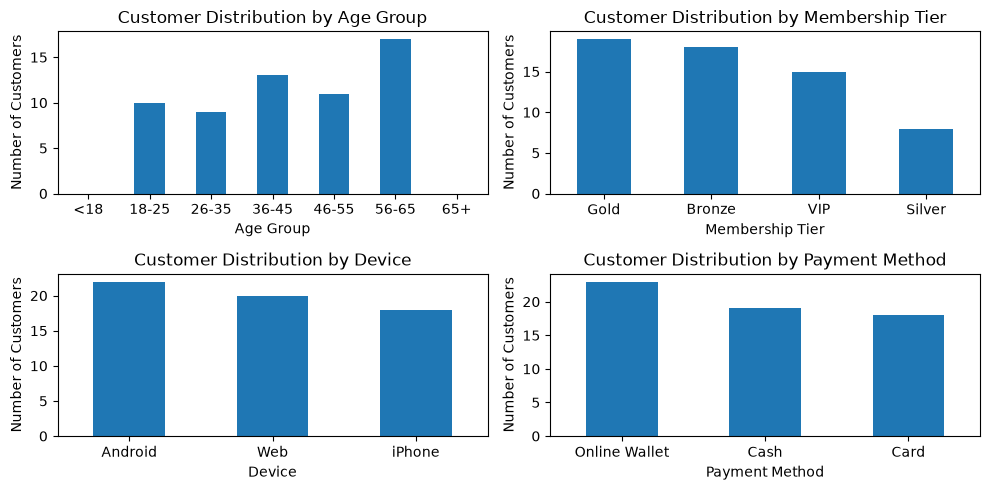

In [10]:
fig, axes = plt.subplots(2,2, figsize=(10, 5))

for col_title, col_value_counts, ax, x_label in [
    ('Customer Distribution by Age Group', age_counts, axes[0, 0], 'Age Group'),
    ('Customer Distribution by Membership Tier', membership_counts, axes[0, 1], 'Membership Tier'),
    ('Customer Distribution by Device', device_counts, axes[1, 0], 'Device'),
    ('Customer Distribution by Payment Method', payment_method_counts, axes[1, 1], 'Payment Method'),
]:
    col_value_counts.plot(kind='bar', ax=ax)
    ax.set_title(col_title);
    ax.set_xlabel(x_label);
    ax.set_ylabel('Number of Customers');
    ax.tick_params(axis='x', rotation=0);
    
plt.tight_layout()
plt.show()

## 2. City for invest

In [11]:
location_df = df.dropna(
    subset=["province", "city", "customer_id", "total_spending", "satisfaction_score", "purchase_count"]
).copy()


location_df["avg_order_value"] = location_df["total_spending"] / location_df["purchase_count"]


city_summary = (
    location_df.groupby(["province", "city"], as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_customer_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

city_summary = city_summary[city_summary["customer_count"] >= 3].copy()
top_cities_total_revenue = city_summary.nlargest(10, "total_revenue").sort_values("total_revenue")
top_cities_avg_customer_spending = city_summary.nlargest(10, "avg_customer_spending").sort_values("avg_customer_spending")

display(top_cities_total_revenue.sort_values("total_revenue", ascending=False))

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,64118.44,5828.949091,22.636364,283.658042,2.909091
1,East Azerbaijan,Tabriz,12,36192.49,3016.040833,15.750000,238.901667,3.000000
0,Alborz,Karaj,7,26189.81,3741.401429,16.000000,211.440000,2.857143
6,Khuzestan,Ahvaz,8,23384.78,2923.097500,13.875000,238.368571,3.500000
4,Isfahan,Isfahan,5,21975.32,4395.064000,19.800000,212.680000,4.400000
2,Fars,Shiraz,6,20715.92,3452.653333,16.333333,180.983333,2.000000
3,Gilan,Rasht,5,15168.54,3033.708000,16.400000,241.554000,2.600000
7,Tehran,Tehran,6,15161.29,2526.881667,17.166667,172.930000,2.666667


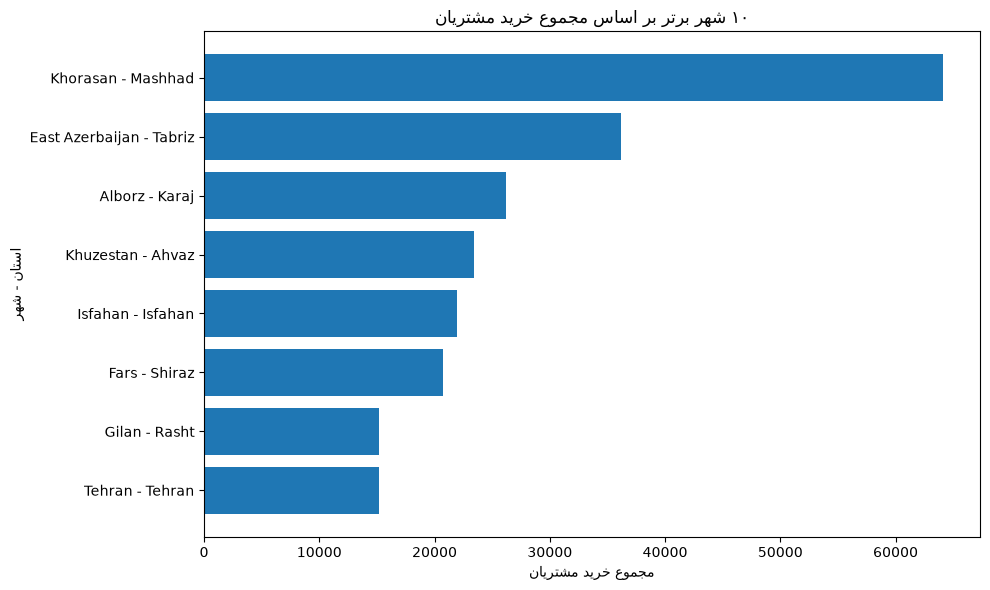

In [12]:
labels = top_cities_total_revenue["province"] + " - " + top_cities_total_revenue["city"]
plt.figure(figsize=(10, 6))
plt.barh(labels, top_cities_total_revenue["total_revenue"])
plt.title("۱۰ شهر برتر بر اساس مجموع خرید مشتریان")
plt.xlabel("مجموع خرید مشتریان")
plt.ylabel("استان - شهر")
plt.tight_layout()
plt.show()

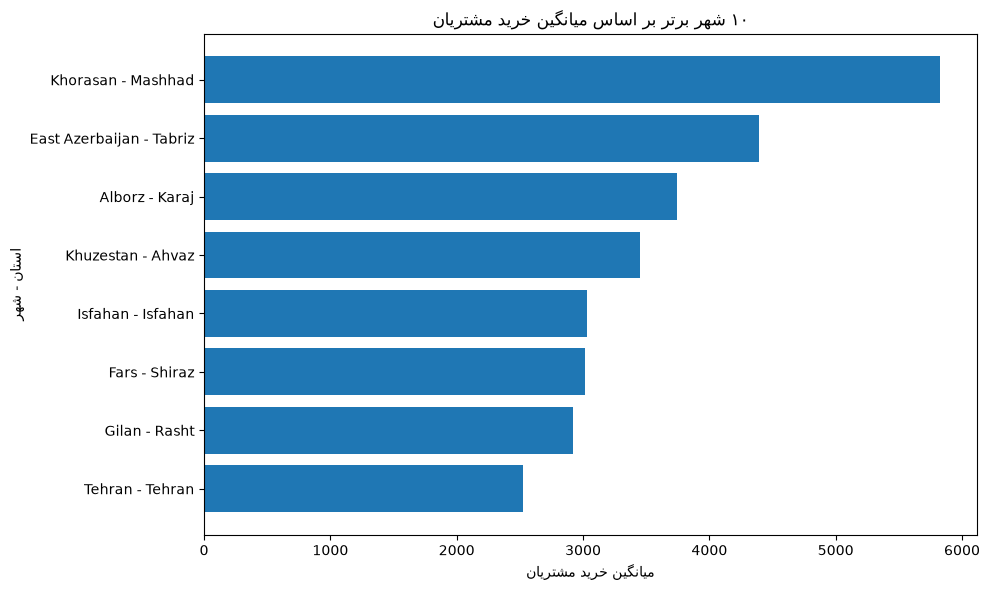

In [13]:
plt.figure(figsize=(10, 6))
plt.barh(labels, top_cities_avg_customer_spending["avg_customer_spending"])
plt.title("۱۰ شهر برتر بر اساس میانگین خرید مشتریان")
plt.xlabel("میانگین خرید مشتریان")
plt.ylabel("استان - شهر")
plt.tight_layout()
plt.show()

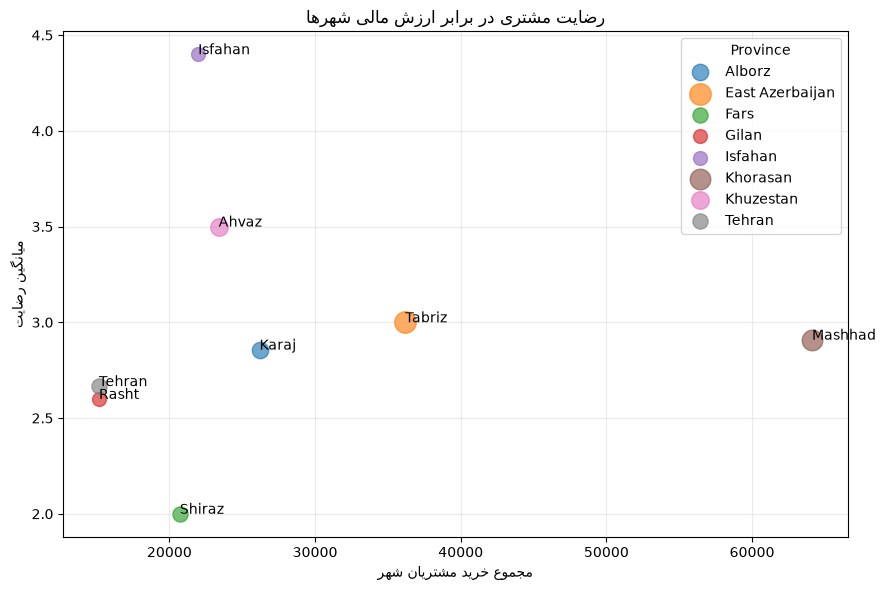

In [14]:
plt.figure(figsize=(9, 6))

for province, group in city_summary.groupby("province"):
    plt.scatter(
        group["total_revenue"],
        group["avg_satisfaction"],
        s=group["customer_count"] * 20,
        alpha=0.65,
        label=province
    )
    

plt.legend(title="Province")

for _, row in city_summary.iterrows():
    plt.annotate(
        row["city"],
        (row["total_revenue"], row["avg_satisfaction"])
    )
    
plt.title("رضایت مشتری در برابر ارزش مالی شهرها")
plt.xlabel("مجموع خرید مشتریان شهر")
plt.ylabel("میانگین رضایت")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [15]:
recommended_city = city_summary.sort_values(
    ["total_revenue", "avg_satisfaction", "customer_count"],
    ascending=[False, False, False]
).head(1)
recommended_city

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,64118.44,5828.949091,22.636364,283.658042,2.909091


### Metric to recommend city
* Market penetration
* Customer economic value
* Customer health/experience

#### Metric 1:

In [16]:
# Market penetration -> Customer count 
cc = city_summary["customer_count"]
cc_norm = (cc - cc.min()) / (cc.max() - cc.min())

# Customer economic value -> Revenue per customer
rpc = city_summary["total_revenue"] / city_summary["customer_count"]
rpc_norm = (rpc - rpc.min()) / (rpc.max() - rpc.min())

# Customer health/experience -> Average satisfaction score
ss =  city_summary["avg_satisfaction"]
ss_norm = (ss - ss.min()) / (ss.max() - ss.min())

city_summary["metric1"] = 0.4 * rpc_norm + 0.35 * ss_norm + 0.25 * cc_norm

city_summary.sort_values(["metric1"], ascending= [False]).head(2)

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction,metric1
5,Khorasan,Mashhad,11,64118.44,5828.949091,22.636364,283.658042,2.909091,0.746861
4,Isfahan,Isfahan,5,21975.32,4395.064000,19.800000,212.680000,4.400000,0.576305


#### Metric 2: Using ranks (Even more robust than previous metric)

In [17]:
cc_rank = city_summary['customer_count'].rank(axis=0, method='average', ascending=False)

rpc_rank = rpc.rank(axis=0, method='average', ascending=False)

ss_rank = city_summary['avg_satisfaction'].rank(axis=0, method='average', ascending=False)

N = city_summary.shape[0]

cc_rank = 1 - (cc_rank-1)/(N-1)
rpc_rank = 1 - (rpc_rank-1)/(N-1)
ss_rank = 1 - (ss_rank-1)/(N-1)

city_summary['cc_rank'] = cc_rank
city_summary['rpc_rank'] = rpc_rank
city_summary['ss_rank'] = ss_rank
city_summary['total_rank'] = 0.4 * rpc_rank + 0.35 * ss_rank + 0.25 * cc_rank

city_summary[['province','city', 'cc_rank', 'rpc_rank', 'ss_rank', 'total_rank']].sort_values('total_rank', ascending=False).head(2)

,province,city,cc_rank,rpc_rank,ss_rank,total_rank
5,Khorasan,Mashhad,0.857143,1.000000,0.571429,0.814286
4,Isfahan,Isfahan,0.071429,0.857143,1.000000,0.710714


# 3. Loyal customers

In [18]:
loyalty_df = df.dropna(subset=['customer_id', 'first_name', 'membership_tier', 'purchase_count', 'total_spending', 'last_purchase_days', 'satisfaction_score']).copy()
tier_map = {
    "Bronze": 0,
    "Silver": 1,
    "Gold": 2,
    "VIP": 3
}

loyalty_df['membership_tier'] = loyalty_df["membership_tier"].map(tier_map)

loyalty_score_cols = {
    'purchase_count':'purchase_count_score',
    'total_spending':'total_spending_score',
    'satisfaction_score':'satisfaction_score_score', 
    'last_purchase_days':'recency_score',
    'membership_tier':'membership_tier_score'
    }


# noramlize by min-max
for col, score_col_name in loyalty_score_cols.items():
    x = loyalty_df[col]
    if x.max() == x.min():
        loyalty_df[score_col_name] = 1.0
    else:
        loyalty_df[score_col_name] = (x - x.min()) / (x.max() - x.min())

loyalty_df["recency_score"] = 1 - loyalty_df["recency_score"]        

loyalty_df["loyalty_score"] = (
    0.30 * loyalty_df["total_spending_score"]
    + 0.25 * loyalty_df["purchase_count_score"]
    + 0.20 * loyalty_df["recency_score"]
    + 0.15 * loyalty_df["satisfaction_score_score"]
    + 0.1 * loyalty_df["membership_tier_score"]
)

top_loyal_customers = loyalty_df.sort_values("loyalty_score", ascending=False).head(10)

top_loyal_customers[['customer_id', 'first_name', 'membership_tier','loyalty_score'] + list(loyalty_score_cols.values())]


,customer_id,first_name,membership_tier,loyalty_score,purchase_count_score,total_spending_score,satisfaction_score_score,recency_score,membership_tier_score
29,1030,Sina,3,0.712026,0.742857,1.000000,0.75,0.069061,1.000000
56,1057,Maryam,0,0.652675,0.885714,0.541310,0.75,0.781768,0.000000
32,1033,Neda,3,0.627462,0.685714,0.220848,1.00,0.698895,1.000000
58,1059,Ali,2,0.622778,0.885714,0.355942,1.00,0.389503,0.666667
43,1044,Mina,2,0.622630,0.942857,0.574174,0.25,0.552486,0.666667
13,1014,Reza,3,0.622242,0.885714,0.134156,0.75,0.740331,1.000000
3,1004,Sina,2,0.596468,0.657143,0.244858,0.75,0.897790,0.666667
16,1017,Parsa,3,0.592730,0.857143,0.129576,0.75,0.635359,1.000000
0,1001,Reza,3,0.589038,0.485714,0.082640,1.00,0.964088,1.000000
42,1043,Kimia,3,0.561029,0.657143,0.041400,0.75,0.859116,1.000000


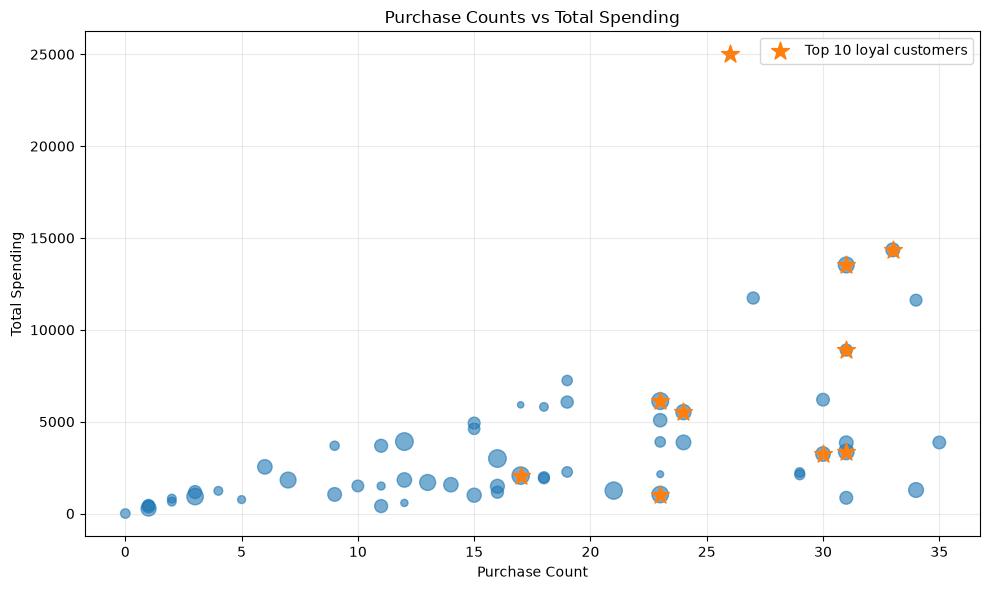

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(
loyalty_df["purchase_count"],
loyalty_df["total_spending"],
s=(loyalty_df["recency_score"] + 0.15) * 140,
alpha=0.6,    
)

plt.scatter(
    top_loyal_customers['purchase_count'], 
    top_loyal_customers['total_spending'],
    s=180, marker='*',
    label = 'Top 10 loyal customers')

plt.title('Purchase Counts vs Total Spending')
plt.xlabel('Purchase Count')
plt.ylabel('Total Spending')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 4. Churn prediction

In [20]:
risk_df = df.dropna(subset=['customer_id', 'first_name', 'membership_tier', 'purchase_count', 'total_spending', 'last_purchase_days', 'satisfaction_score']).copy()

spending_threshold = risk_df["total_spending"].quantile(0.75)
purchase_threshold = risk_df["purchase_count"].median()
inactivity_threshold = risk_df["last_purchase_days"].quantile(0.75)

In [21]:
risk_df["at_risk"] = (
(risk_df["total_spending"] >= spending_threshold)
& (risk_df["purchase_count"] >= purchase_threshold)
& (risk_df["last_purchase_days"] >= inactivity_threshold)
)

valuable_at_risk_customers = risk_df.loc[risk_df["at_risk"], [
"customer_id", "first_name", "membership_tier", "purchase_count",
"total_spending", "last_purchase_days", "satisfaction_score"
]].sort_values(
["total_spending", "last_purchase_days"],
ascending=[False, False]
)
valuable_at_risk_customers

,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
29,1030,Sina,VIP,26,25000.00,340,4
9,1010,Arash,Silver,19,7241.47,276,1
34,1035,Arash,Bronze,17,5918.21,365,3
52,1053,Sina,Gold,18,5805.54,320,1


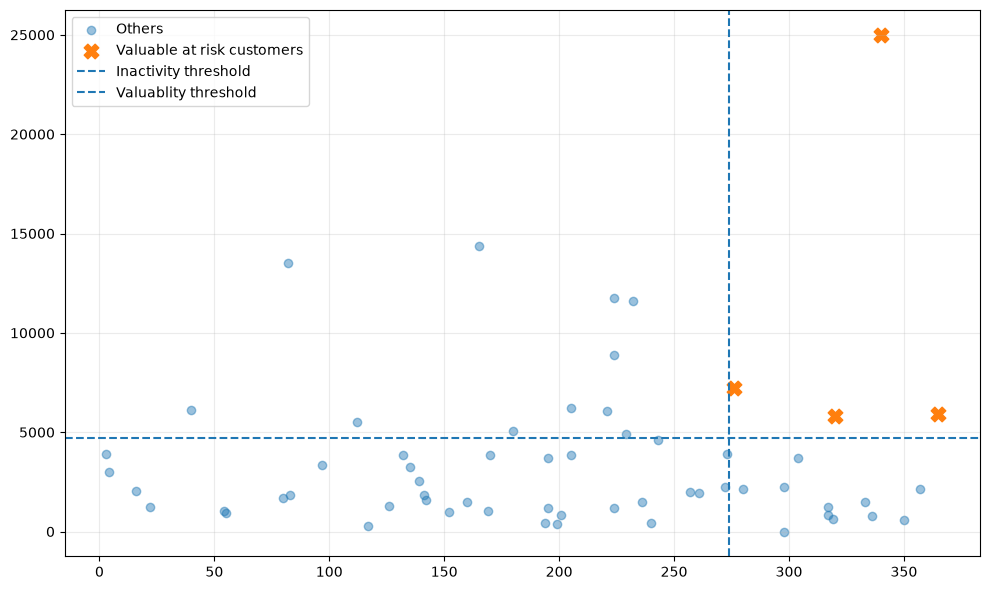

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(
risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
risk_df.loc[~risk_df["at_risk"], "total_spending"],
alpha=0.45,
label = 'Others')    

plt.scatter(
risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
risk_df.loc[risk_df["at_risk"], "total_spending"],
marker="X",
s=110,
label = 'Valuable at risk customers')

plt.axvline(inactivity_threshold, linestyle="--", label = 'Inactivity threshold')
plt.axhline(spending_threshold, linestyle="--", label = 'Valuablity threshold')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# 5. Discount, Device and  Payment method

In [27]:
factor_df = df.dropna(
subset=[
    "discount_used", "device", "payment_method", "total_spending",
    "purchase_count", "returned_items",
    "satisfaction_score"
]
).copy()


factor_df["avg_order_value"] = factor_df["total_spending"] / factor_df["purchase_count"]

summary_by_discount = (
factor_df.groupby("discount_used", as_index=False)
.agg(
    customer_count=("customer_id", "nunique"),
    avg_total_spending=("total_spending", "mean"),
    avg_purchase_count=("purchase_count", "mean"),
    avg_order_value=("avg_order_value", "mean"),
    avg_returned_items=("returned_items", "mean"),
    avg_satisfaction=("satisfaction_score", "mean")
)
)

summary_by_device = (
factor_df.groupby("device", as_index=True)
.agg(
    customer_count=("customer_id", "nunique"),
    avg_total_spending=("total_spending", "mean"),
    avg_purchase_count=("purchase_count", "mean"),
    avg_order_value=("avg_order_value", "mean"),
    avg_returned_items=("returned_items", "mean"),
    avg_satisfaction=("satisfaction_score", "mean")
)
)


summary_by_payment_method = (
factor_df.groupby("payment_method", as_index=True)
.agg(
    customer_count=("customer_id", "nunique"),
    avg_total_spending=("total_spending", "mean"),
    avg_purchase_count=("purchase_count", "mean"),
    avg_order_value=("avg_order_value", "mean"),
    avg_returned_items=("returned_items", "mean"),
    avg_satisfaction=("satisfaction_score", "mean")
)
)

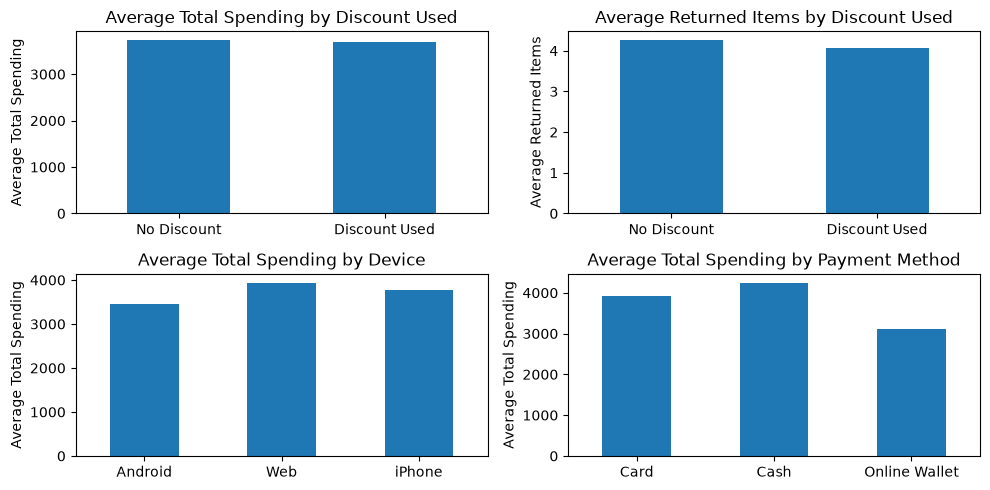

In [32]:
factor_fig, factor_axes = plt.subplots(2,2, figsize=(10, 5))

discount_used = summary_by_discount['discount_used'].map({True:'Discount Used', False:'No Discount'})
summary_by_discount = summary_by_discount.set_index(discount_used)

for ax_title, x, ax, y_label in [
    ('Average Total Spending by Discount Used', summary_by_discount['avg_total_spending'], factor_axes[0, 0], 'Average Total Spending'),
    ('Average Returned Items by Discount Used', summary_by_discount['avg_returned_items'], factor_axes[0, 1], 'Average Returned Items'),
    ('Average Total Spending by Device', summary_by_device['avg_total_spending'], factor_axes[1, 0], 'Average Total Spending'),
    ('Average Total Spending by Payment Method', summary_by_payment_method['avg_total_spending'], factor_axes[1, 1], 'Average Total Spending'),
]:
    x.plot(kind='bar', ax=ax)
    ax.set_title(ax_title);
    ax.set_xlabel('');
    ax.set_ylabel(y_label);
    ax.tick_params(axis='x', rotation=0);
    
plt.tight_layout()
plt.show()